# SIF × Irrigation × Drought — Iowa 2019–2023

Tests whether irrigation decouples plant productivity (SIF) from drought stress.

**Core hypothesis:** In heavily irrigated cropland, plants maintain high SIF even during drought because irrigation supplies water. In rainfed cropland, drought suppresses SIF as expected.

**Data:**
- **ΔET (irrigation signal):** OpenET − NLDAS Noah, monthly, 0.125° — `data/processed/ET_delta/`
- **SIF (plant productivity):** OCO-2 v11r half-monthly NetCDFs, 0.05° → aggregated to 0.125°
- **Drought:** US Drought Monitor biweekly GeoTIFFs (DM 0–4), max of two per month → 0.125°
- **Cropland mask:** CDL-derived, 0.125° NLDAS grid

**Analyses:**
1. Z-score normalization of SIF and ΔET (per-pixel monthly climatology)
2. Z-score time series with drought overlay
3. Violin plots of SIF-z and ΔET-z by drought category
4. Mean SIF vs drought: high-irrigation vs low-irrigation cropland
5. SIF × ΔET scatter colored by drought severity

## 1. Setup

In [1]:
import sys, os
print(f'Python: {sys.executable}')

import matplotlib
_is_hpc = os.environ.get('SLURM_JOB_ID') or os.environ.get('SIF_ROOT')
if _is_hpc:
    matplotlib.use('Agg')

import numpy as np
import pandas as pd
import xarray as xr
import rasterio
import rasterio.transform
from rasterio.warp import reproject
from rasterio.enums import Resampling
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print('seaborn not available — using matplotlib violin plots')

print(f'matplotlib backend: {matplotlib.get_backend()}')
print('Libraries loaded.')

Python: /home/pielab-sandbox-jcoldiron/.venv/bin/python
seaborn not available — using matplotlib violin plots
matplotlib backend: module://matplotlib_inline.backend_inline
Libraries loaded.


In [2]:
_root_env    = os.environ.get('SIF_ROOT')
project_root = Path(_root_env) if _root_env else Path('../../..').resolve()

et_dir        = project_root / 'data' / 'processed' / 'ET_delta'
sif_dir       = project_root / 'data' / 'raw'       / 'SIF_OCO2_005_v11r'
drought_dir   = project_root / 'data' / 'raw'       / 'Iowa_drought_county_biweekly'
mask_dir      = project_root / 'data' / 'processed' / 'cropland_masks'
output_dir    = project_root / 'data' / 'processed' / 'sif_irr_drought'
figures_dir   = project_root / 'figures'            / 'sif_irr_drought'
iowa_boundary = project_root / 'data' / 'aoi'       / 'iowa.geojson'

output_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

iowa_gdf    = gpd.read_file(iowa_boundary)
iowa_bounds = iowa_gdf.total_bounds  # [minx, miny, maxx, maxy]

YEARS          = list(range(2019, 2024))
MONTHS         = list(range(1, 13))
GROWING_SEASON = list(range(4, 11))  # April–October

# USDM drought categories and official colors
DM_LABELS = {0: 'None', 1: 'D0\nAbn.Dry', 2: 'D1\nModerate',
             3: 'D2\nSevere',  4: 'D3+\nExtreme'}
DM_COLORS = {0: '#d4edd4', 1: '#ffff00', 2: '#fcd37f', 3: '#ffaa00', 4: '#e60000'}

print(f'Project root: {project_root}')
print(f'Iowa bounds:  {iowa_bounds}')

Project root: /home/pielab-sandbox-jcoldiron/SIF-Analysis
Iowa bounds:  [-96.63949339  40.37544738 -90.14006749  43.50120364]


## 2. Iowa NLDAS Reference Grid

All data will be reprojected to match the saved delta-ET GeoTIFF grid (0.125°).

In [3]:
et_files = sorted(et_dir.glob('ET_delta_*.tif'))
if not et_files:
    raise FileNotFoundError(f'No ET delta files in {et_dir} — run human_et.ipynb first.')

with rasterio.open(et_files[0]) as src:
    iowa_transform = src.transform
    iowa_shape     = (src.height, src.width)

# Pixel-centre coordinates
iowa_lons = np.array([iowa_transform.c + iowa_transform.a * (c + 0.5)
                      for c in range(iowa_shape[1])])
iowa_lats = np.array([iowa_transform.f + iowa_transform.e * (r + 0.5)
                      for r in range(iowa_shape[0])])

print(f'Iowa NLDAS grid : {iowa_shape[0]} rows x {iowa_shape[1]} cols')
print(f'  Lon: {iowa_lons[0]:.4f} to {iowa_lons[-1]:.4f}')
print(f'  Lat: {iowa_lats[0]:.4f} to {iowa_lats[-1]:.4f}')

Iowa NLDAS grid : 25 rows x 52 cols
  Lon: -96.5625 to -90.1875
  Lat: 43.4375 to 40.4375


## 3. Helper Functions

In [4]:
def load_et_monthly(year, month):
    """Load delta-ET GeoTIFF for one month."""
    path = et_dir / f'ET_delta_{year}{month:02d}_Iowa_cropland.tif'
    if not path.exists():
        return None
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32)


def load_sif_monthly(year, month):
    """Average two OCO-2 half-monthly SIF files, reproject to Iowa NLDAS grid."""
    yyyymm = f'{year}{month:02d}'
    paths  = [sif_dir / f'sif_ann_{yyyymm}a.nc4',
              sif_dir / f'sif_ann_{yyyymm}b.nc4']

    arrays = []
    sif_lats_sub = sif_lons_sub = None

    for p in paths:
        if not p.exists():
            continue
        ds  = xr.open_dataset(p)
        sub = ds['sif_ann'].sel(
            latitude =slice(iowa_bounds[1] - 0.5, iowa_bounds[3] + 0.5),
            longitude=slice(iowa_bounds[0] - 0.5, iowa_bounds[2] + 0.5),
        )
        if sif_lats_sub is None:
            sif_lats_sub = sub.latitude.values.copy()
            sif_lons_sub = sub.longitude.values.copy()
        arrays.append(sub.values.astype(np.float32))
        ds.close()

    if not arrays:
        return None

    sif_mean = np.nanmean(arrays, axis=0)

    # OCO-2 latitude is ascending (south->north); rasterio needs north-up -> flip
    sif_res = float(abs(sif_lats_sub[1] - sif_lats_sub[0]))
    if sif_lats_sub[0] < sif_lats_sub[-1]:
        sif_mean   = sif_mean[::-1, :]
        north_edge = float(sif_lats_sub[-1]) + sif_res / 2
    else:
        north_edge = float(sif_lats_sub[0])  + sif_res / 2

    src_tfm = rasterio.transform.from_origin(
        west  = float(sif_lons_sub[0]) - sif_res / 2,
        north = north_edge,
        xsize = sif_res,
        ysize = sif_res,
    )

    dst = np.full(iowa_shape, np.nan, dtype=np.float32)
    reproject(
        source=sif_mean, destination=dst,
        src_transform=src_tfm, src_crs='EPSG:4326', src_nodata=np.nan,
        dst_transform=iowa_transform, dst_crs='EPSG:4326',
        resampling=Resampling.average,
    )
    return dst


def load_drought_monthly(year, month):
    """Max of two USDM biweekly rasters, rounded to integer DM category, on Iowa grid."""
    yyyymm_str = f'{year}-{month:02d}'
    paths = [
        drought_dir / f'Iowa_county_drought_DM_{yyyymm_str}_1.tif',
        drought_dir / f'Iowa_county_drought_DM_{yyyymm_str}_2.tif',
    ]

    arrays = []
    src_tfm = src_crs_val = None
    for p in paths:
        if not p.exists():
            continue
        with rasterio.open(p) as src:
            arr = src.read(1).astype(np.float32)
            if src_tfm is None:
                src_tfm     = src.transform
                src_crs_val = src.crs
        arrays.append(arr)

    if not arrays:
        return None

    dm_max = np.fmax(arrays[0], arrays[1]) if len(arrays) == 2 else arrays[0]

    dst = np.full(iowa_shape, np.nan, dtype=np.float32)
    reproject(
        source=dm_max, destination=dst,
        src_transform=src_tfm, src_crs=src_crs_val, src_nodata=np.nan,
        dst_transform=iowa_transform, dst_crs='EPSG:4326',
        resampling=Resampling.average,
    )
    # Round fractional values (county boundary blending) to integer DM categories
    out = np.full(iowa_shape, np.nan, dtype=np.float32)
    valid = ~np.isnan(dst)
    out[valid] = np.round(dst[valid])
    return out


def load_iowa_cropland_mask(year):
    """Reproject CONUS cropland-fraction GeoTIFF to Iowa NLDAS grid."""
    frac_path = mask_dir / f'cropland_fraction_{year}_nldas.tif'
    if not frac_path.exists():
        return None
    with rasterio.open(frac_path) as src:
        frac    = src.read(1).astype(np.float32)
        src_tfm = src.transform
        src_crs = src.crs

    dst = np.full(iowa_shape, np.nan, dtype=np.float32)
    reproject(
        source=frac, destination=dst,
        src_transform=src_tfm, src_crs=src_crs, src_nodata=np.nan,
        dst_transform=iowa_transform, dst_crs='EPSG:4326',
        resampling=Resampling.nearest,
    )
    return dst >= 0.5


print('Helper functions defined.')

Helper functions defined.


## 4. Build Monthly Aligned Dataset

Load all 60 months of delta-ET, SIF, drought, and cropland mask onto the same Iowa 0.125° grid.

Expect a few minutes on first run (loading ~120 SIF NetCDFs).

In [5]:
n_months = len(YEARS) * len(MONTHS)  # 60

et_cube      = np.full((n_months, *iowa_shape), np.nan, dtype=np.float32)
sif_cube     = np.full((n_months, *iowa_shape), np.nan, dtype=np.float32)
drought_cube = np.full((n_months, *iowa_shape), np.nan, dtype=np.float32)
mask_cube    = np.full((n_months, *iowa_shape), False,  dtype=bool)

time_rows = []
skipped   = []

for i, (year, month) in enumerate([(y, m) for y in YEARS for m in MONTHS]):
    yyyymm = f'{year}{month:02d}'
    time_rows.append({'i': i, 'year': year, 'month': month, 'yyyymm': yyyymm})

    et  = load_et_monthly(year, month)
    sif = load_sif_monthly(year, month)
    drg = load_drought_monthly(year, month)
    msk = load_iowa_cropland_mask(year)

    if et is None:
        skipped.append(yyyymm)
        print(f'  SKIP {yyyymm}: missing ET delta')
        continue

    et_cube[i] = et
    if sif is not None: sif_cube[i]     = sif
    if drg is not None: drought_cube[i] = drg
    if msk is not None: mask_cube[i]    = msk

    sif_mean = float(np.nanmean(sif)) if sif is not None else float('nan')
    dm_mean  = float(np.nanmean(drg)) if drg is not None else float('nan')
    et_mean  = float(np.nanmean(et))
    print(f'  {yyyymm}: DeltaET={et_mean:+6.1f} mm  SIF={sif_mean:.3f}  DM={dm_mean:.2f}')

time_df = pd.DataFrame(time_rows)
print(f'\nLoaded {n_months - len(skipped)}/60 months.  Skipped: {skipped}')

  201901: DeltaET=  -0.7 mm  SIF=0.012  DM=nan
  201902: DeltaET=  -2.6 mm  SIF=0.027  DM=nan
  201903: DeltaET=  +6.3 mm  SIF=0.012  DM=nan
  201904: DeltaET= +14.6 mm  SIF=0.066  DM=nan
  201905: DeltaET=  +4.0 mm  SIF=0.157  DM=nan
  201906: DeltaET=  +9.2 mm  SIF=0.296  DM=nan
  201907: DeltaET= +10.9 mm  SIF=0.583  DM=0.00
  201908: DeltaET=  +9.0 mm  SIF=0.583  DM=0.15
  201909: DeltaET=  -2.3 mm  SIF=0.343  DM=0.09
  201910: DeltaET=  -3.2 mm  SIF=0.092  DM=nan
  201911: DeltaET=  +5.4 mm  SIF=0.020  DM=nan
  201912: DeltaET=  +3.5 mm  SIF=0.017  DM=nan
  202001: DeltaET=  +0.1 mm  SIF=0.015  DM=nan
  202002: DeltaET=  +7.4 mm  SIF=0.010  DM=nan
  202003: DeltaET=  +6.3 mm  SIF=0.014  DM=nan
  202004: DeltaET= +14.4 mm  SIF=0.063  DM=nan
  202005: DeltaET=  +5.6 mm  SIF=0.170  DM=0.00
  202006: DeltaET=  +8.4 mm  SIF=0.378  DM=0.00
  202007: DeltaET= +20.1 mm  SIF=0.662  DM=0.54
  202008: DeltaET= +36.5 mm  SIF=0.515  DM=1.04
  202009: DeltaET= +12.3 mm  SIF=0.218  DM=0.92
  202

## 5. Compute Z-Scores

For each pixel and each calendar month, z-score across the 5 available years:

```
z(year, month, pixel) = (value - mean_over_years) / std_over_years
```

This removes the seasonal cycle so summer SIF and winter SIF are on the same anomaly scale.

In [6]:
sif_z_cube = np.full_like(sif_cube, np.nan)
et_z_cube  = np.full_like(et_cube,  np.nan)

for m in range(1, 13):
    m_idx = [row['i'] for _, row in time_df.iterrows() if row['month'] == m]

    sif_slice = sif_cube[m_idx]  # shape (n_years, rows, cols)
    et_slice  = et_cube[m_idx]

    with np.errstate(invalid='ignore', divide='ignore'):
        sif_mean = np.nanmean(sif_slice, axis=0)
        sif_std  = np.nanstd( sif_slice, axis=0, ddof=1)
        et_mean  = np.nanmean(et_slice,  axis=0)
        et_std   = np.nanstd( et_slice,  axis=0, ddof=1)

    for local_j, global_i in enumerate(m_idx):
        with np.errstate(invalid='ignore', divide='ignore'):
            sif_z_cube[global_i] = (sif_cube[global_i] - sif_mean) / sif_std
            et_z_cube[global_i]  = (et_cube[global_i]  - et_mean)  / et_std

print('Z-scores computed.')
print(f'  SIF-z : {np.nanmin(sif_z_cube):.2f} to {np.nanmax(sif_z_cube):.2f}')
print(f'  DeltaET-z: {np.nanmin(et_z_cube):.2f} to {np.nanmax(et_z_cube):.2f}')

Z-scores computed.
  SIF-z : -1.79 to 1.79
  DeltaET-z: -1.79 to 1.79


## 6. Build Analysis DataFrame

Flatten 3D cubes to a tidy DataFrame — one row per (month, pixel). Filter to cropland, growing season.

In [7]:
rows = []

for _, trow in time_df.iterrows():
    i     = int(trow['i'])
    year  = int(trow['year'])
    month = int(trow['month'])
    crop  = mask_cube[i]
    if not crop.any():
        continue

    rows.append(pd.DataFrame({
        'year':    year,
        'month':   month,
        'yyyymm':  trow['yyyymm'],
        'et':      et_cube[i][crop],
        'sif':     sif_cube[i][crop],
        'drought': drought_cube[i][crop],
        'sif_z':   sif_z_cube[i][crop],
        'et_z':    et_z_cube[i][crop],
    }))

df = pd.concat(rows, ignore_index=True)

# Growing-season, drop rows missing any key variable
df_gs_clean = (
    df[df['month'].isin(GROWING_SEASON)]
    .dropna(subset=['et', 'sif', 'drought'])
    .copy()
)
df_gs_clean['dm_cat'] = df_gs_clean['drought'].astype(int)

print(f'Total cropland pixel-months:          {len(df):,}')
print(f'Growing-season (Apr-Oct) after clean: {len(df_gs_clean):,}')
print('\nDrought category counts:')
for c, n in df_gs_clean['dm_cat'].value_counts().sort_index().items():
    print(f'  {c} ({DM_LABELS[c]}): {n:,}')

Total cropland pixel-months:          46,992
Growing-season (Apr-Oct) after clean: 19,409

Drought category counts:
  0 (None): 8,296
  1 (D0
Abn.Dry): 5,253
  2 (D1
Moderate): 4,854
  3 (D2
Severe): 950
  4 (D3+
Extreme): 56


## 7. Z-Score Time Series with Drought Overlay

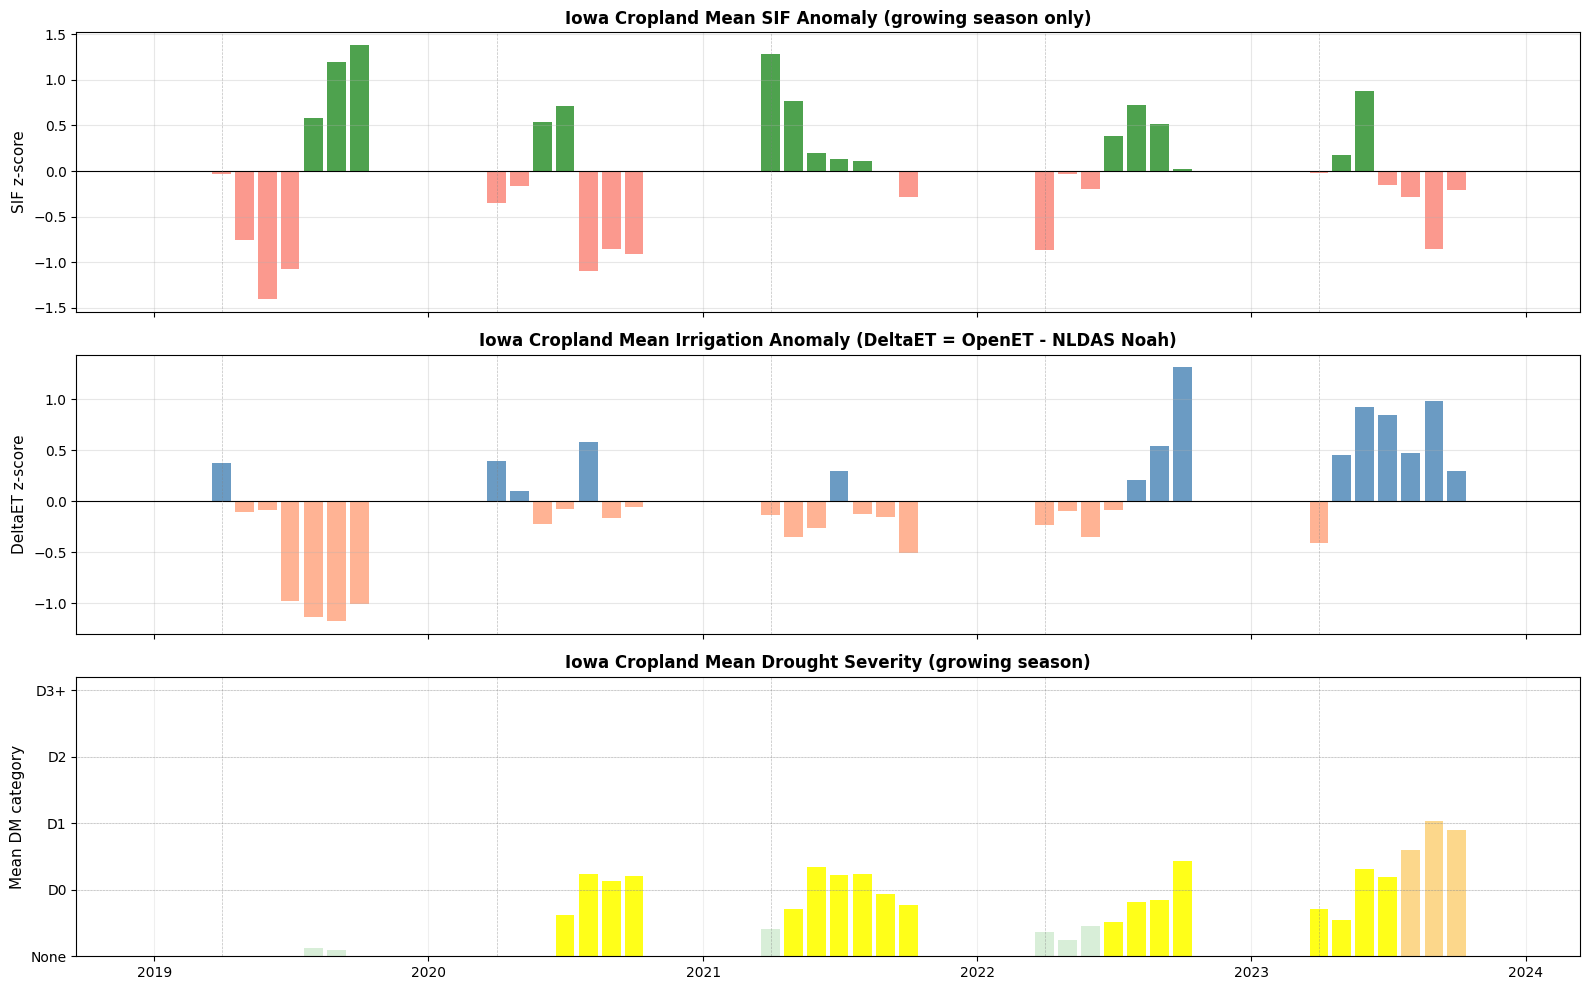

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/zscore_timeseries.png


In [8]:
# Iowa-wide spatial mean of z-scores per month
ts_rows = []
for _, trow in time_df.iterrows():
    i     = int(trow['i'])
    month = int(trow['month'])
    crop  = mask_cube[i]
    in_gs = month in GROWING_SEASON
    ts_rows.append({
        'year':    int(trow['year']),
        'month':   month,
        'yyyymm':  trow['yyyymm'],
        'sif_z':   float(np.nanmean(sif_z_cube[i][crop])) if (crop.any() and in_gs) else np.nan,
        'et_z':    float(np.nanmean(et_z_cube[i][crop]))  if (crop.any() and in_gs) else np.nan,
        'dm_mean': float(np.nanmean(drought_cube[i][crop])) if (crop.any() and in_gs) else np.nan,
    })

ts_df = pd.DataFrame(ts_rows)
ts_df['date'] = pd.to_datetime(ts_df['yyyymm'], format='%Y%m')

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Panel 1: SIF z-score
ax = axes[0]
colors = ['forestgreen' if v >= 0 else 'salmon' for v in ts_df['sif_z'].fillna(0)]
ax.bar(ts_df['date'], ts_df['sif_z'], width=25, color=colors, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('SIF z-score', fontsize=11)
ax.set_title('Iowa Cropland Mean SIF Anomaly (growing season only)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 2: DeltaET z-score
ax = axes[1]
colors = ['steelblue' if v >= 0 else 'lightsalmon' for v in ts_df['et_z'].fillna(0)]
ax.bar(ts_df['date'], ts_df['et_z'], width=25, color=colors, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('DeltaET z-score', fontsize=11)
ax.set_title('Iowa Cropland Mean Irrigation Anomaly (DeltaET = OpenET - NLDAS Noah)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 3: Mean drought
ax = axes[2]
dm_bar_colors = [
    DM_COLORS.get(int(round(v)), '#aaaaaa') if not np.isnan(v) else '#eeeeee'
    for v in ts_df['dm_mean']
]
ax.bar(ts_df['date'], ts_df['dm_mean'].fillna(0), width=25, color=dm_bar_colors, alpha=0.9)
for cat in range(5):
    ax.axhline(cat, color='gray', lw=0.4, linestyle=':')
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(['None', 'D0', 'D1', 'D2', 'D3+'])
ax.set_ylabel('Mean DM category', fontsize=11)
ax.set_title('Iowa Cropland Mean Drought Severity (growing season)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.2)

for year in YEARS:
    for a in axes:
        a.axvline(pd.Timestamp(f'{year}-04-01'), color='gray', lw=0.5, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig(figures_dir / 'zscore_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/zscore_timeseries.png')

## 8. Violin Plots — SIF and ΔET Distributions by Drought Category

Growing season, cropland pixels only. Shows the full spread within each drought category.

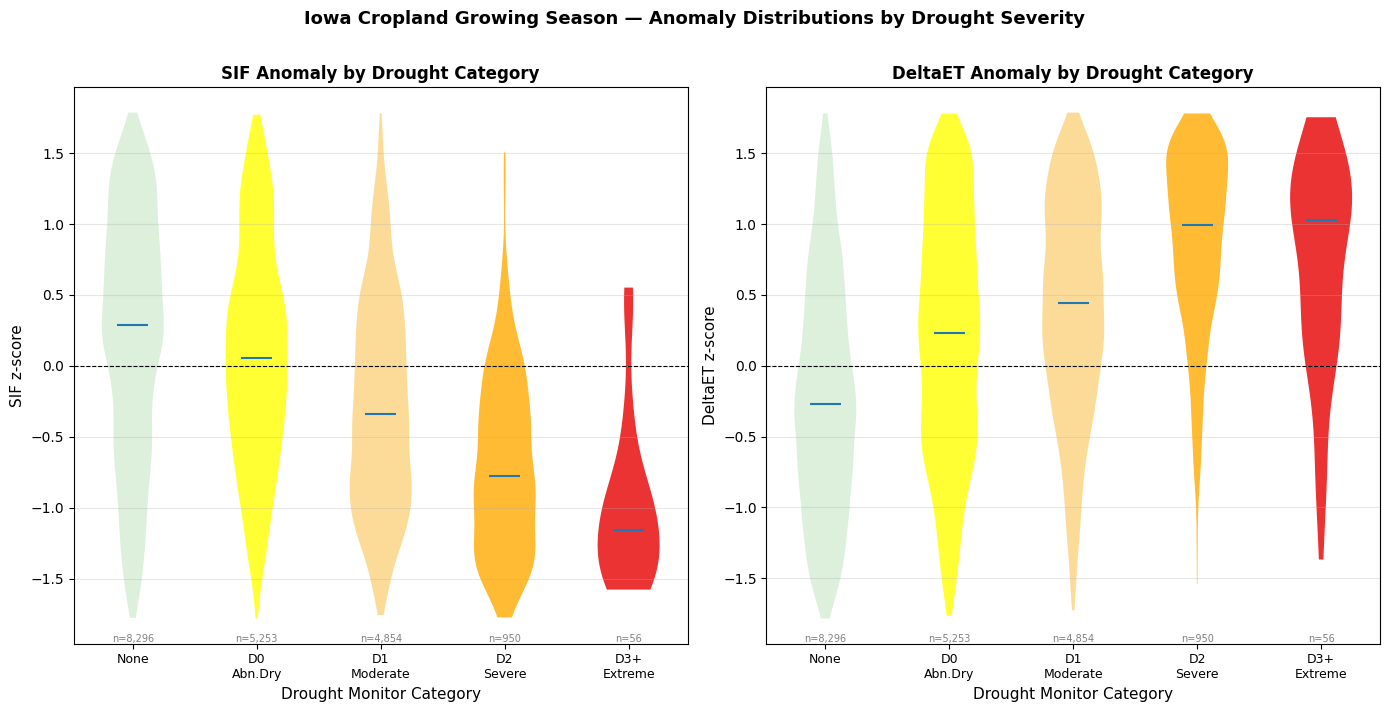

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/violin_by_drought.png


In [9]:
present_cats = sorted(df_gs_clean['dm_cat'].unique())
cat_labels   = [DM_LABELS[c] for c in present_cats]
cat_colors   = [DM_COLORS[c] for c in present_cats]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, var, title, ylabel in [
    (axes[0], 'sif_z', 'SIF Anomaly by Drought Category',  'SIF z-score'),
    (axes[1], 'et_z',  'DeltaET Anomaly by Drought Category', 'DeltaET z-score'),
]:
    data_by_cat = [df_gs_clean.loc[df_gs_clean['dm_cat'] == c, var].dropna().values
                   for c in present_cats]

    if HAS_SEABORN:
        plot_df = df_gs_clean[['dm_cat', var]].dropna().copy()
        sns.violinplot(
            data=plot_df, x='dm_cat', y=var, ax=ax,
            order=present_cats,
            palette={c: DM_COLORS[c] for c in present_cats},
            inner='box', linewidth=1.2, cut=1,
        )
    else:
        parts = ax.violinplot(data_by_cat, positions=present_cats,
                              showmedians=True, showextrema=False)
        for pc, col in zip(parts['bodies'], cat_colors):
            pc.set_facecolor(col)
            pc.set_alpha(0.8)

    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xticks(present_cats)
    ax.set_xticklabels(cat_labels, fontsize=9)
    ax.set_xlabel('Drought Monitor Category', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Sample size annotation
    ymin = ax.get_ylim()[0]
    for c in present_cats:
        n = int((df_gs_clean['dm_cat'] == c).sum())
        ax.annotate(f'n={n:,}', xy=(c, ymin), ha='center', va='bottom', fontsize=7, color='gray')

plt.suptitle('Iowa Cropland Growing Season — Anomaly Distributions by Drought Severity',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(figures_dir / 'violin_by_drought.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/violin_by_drought.png')

## 9. Does Irrigation Decouple SIF from Drought?

Split cropland pixels into **high-irrigation** (ΔET ≥ median) and **low-irrigation** (ΔET < median), then compare how mean SIF changes across drought categories.

**Expected result:** Low-irrigation SIF drops with increasing drought; high-irrigation SIF stays elevated.

In [ ]:
median_et = df_gs_clean['et'].median()
print(f'Median growing-season DeltaET (cropland): {median_et:.1f} mm/month')

df_gs_clean['irr_group'] = np.where(
    df_gs_clean['et'] >= median_et, 'High irrigation', 'Low irrigation'
)

summary_sif  = (df_gs_clean.groupby(['irr_group', 'dm_cat'])['sif']
                .agg(['mean', 'sem', 'count']).reset_index())
summary_sifz = (df_gs_clean.groupby(['irr_group', 'dm_cat'])['sif_z']
                .agg(['mean', 'sem', 'count']).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

group_styles = {
    'High irrigation': {'color': 'steelblue', 'marker': 'o', 'ls': '-'},
    'Low irrigation':  {'color': 'darkorange', 'marker': 's', 'ls': '--'},
}

for ax, smry, ylabel, title in [
    (axes[0], summary_sif,  'Mean SIF (W/m2/sr/um)',
     'Absolute SIF by Drought x Irrigation'),
    (axes[1], summary_sifz, 'Mean SIF z-score',
     'SIF Anomaly by Drought x Irrigation'),
]:
    for group, style in group_styles.items():
        sub = smry[smry['irr_group'] == group].sort_values('dm_cat')
        if sub.empty:
            continue
        ax.errorbar(
            sub['dm_cat'], sub['mean'],
            yerr=1.96 * sub['sem'],
            label=f"{group}",
            color=style['color'], marker=style['marker'],
            linestyle=style['ls'], linewidth=2, markersize=8,
            capsize=4, capthick=1.5,
        )

    ax.set_xticks(present_cats)
    ax.set_xticklabels(cat_labels, fontsize=9)
    ax.set_xlabel('Drought Monitor Category', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    if 'z-score' in ylabel:
        ax.axhline(0, color='black', lw=0.6, ls=':')

plt.suptitle(
    f'Iowa Cropland (Apr-Oct) | Irrigation split at median DeltaET = {median_et:.0f} mm/month\n'
    f'Error bars = 95% CI',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(figures_dir / 'sif_by_drought_x_irrigation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/sif_by_drought_x_irrigation.png')

## 10. SIF × ΔET Scatter Colored by Drought

Each point = one (pixel, month) growing-season observation. Color = drought category.

Look for: high-ΔET (irrigated) pixels maintaining high SIF even under drought (red/orange points on the right side should still sit high on the y-axis).

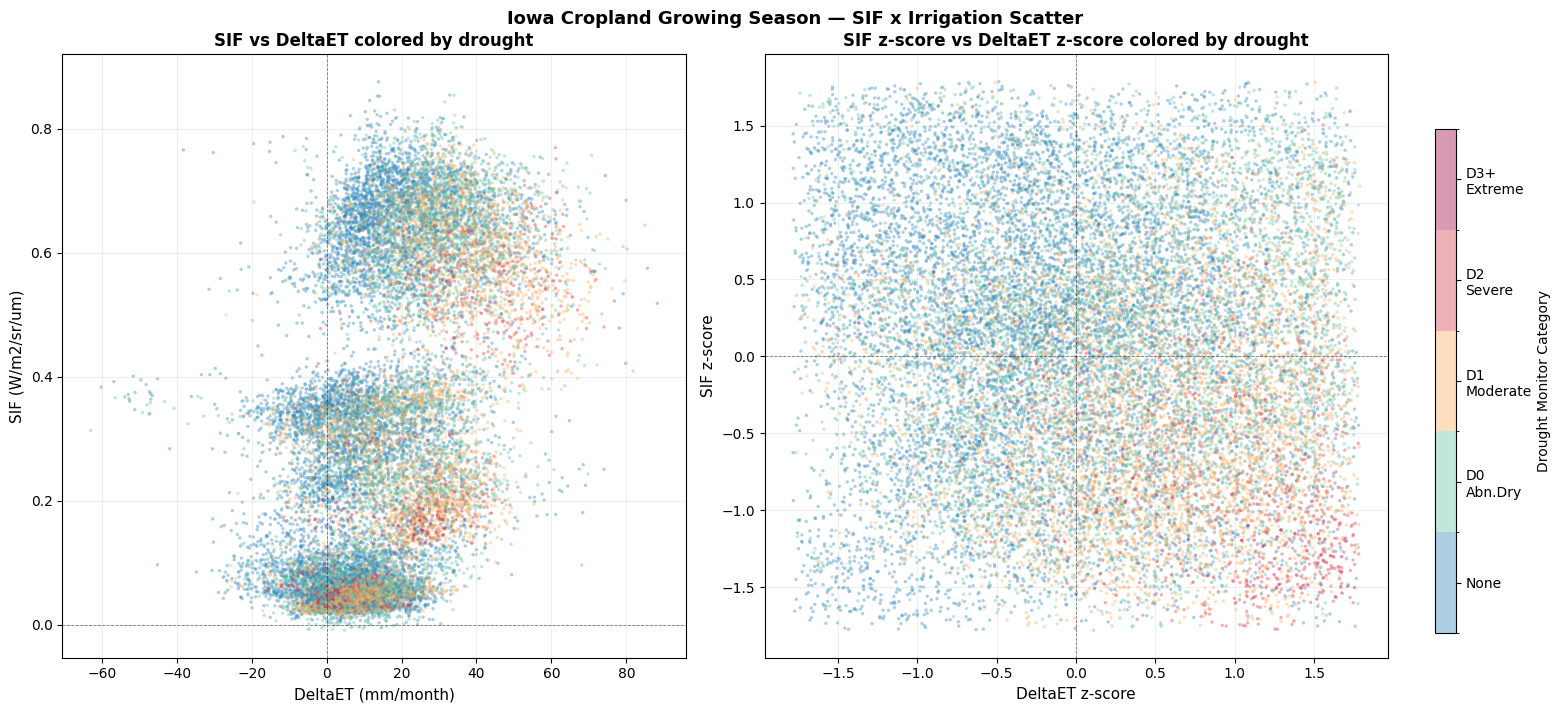

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/sif_irr_scatter.png


In [15]:
# Subsample if large (keeps rendering fast)
plot_df = df_gs_clean.copy()
if len(plot_df) > 50_000:
    plot_df = plot_df.sample(50_000, random_state=42)
    print(f'Subsampled to 50,000 points for plotting.')

# Spectral-derived 5-class palette — blue→teal→orange→red→deep crimson
# More saturated and perceptually distinct than the USDM pastels at small alpha
scatter_dm_colors = ['#3288BD', '#66C2A5', '#FDAE61', '#D53E4F', '#9E0142']
dm_cmap = mcolors.ListedColormap(scatter_dm_colors)
dm_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], len(scatter_dm_colors))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, xcol, ycol, xlabel, ylabel, title in [
    (axes[0], 'et',   'sif',   'DeltaET (mm/month)',  'SIF (W/m2/sr/um)',
     'SIF vs DeltaET colored by drought'),
    (axes[1], 'et_z', 'sif_z', 'DeltaET z-score', 'SIF z-score',
     'SIF z-score vs DeltaET z-score colored by drought'),
]:
    sub = plot_df.dropna(subset=[xcol, ycol, 'dm_cat'])
    sc = ax.scatter(
        sub[xcol], sub[ycol],
        c=sub['dm_cat'], cmap=dm_cmap, norm=dm_norm,
        s=6, alpha=0.4, linewidths=0,
    )
    ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.5)
    ax.axvline(0, color='black', lw=0.6, ls='--', alpha=0.5)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.2)

# Dedicated colorbar axes outside the scatter plots — doesn't steal space from either panel
plt.tight_layout(rect=[0, 0, 0.88, 1])
cbar_ax = fig.add_axes([0.90, 0.12, 0.013, 0.72])
cbar = fig.colorbar(sc, cax=cbar_ax, ticks=[0, 1, 2, 3, 4])
cbar.set_ticklabels([DM_LABELS[k] for k in [0, 1, 2, 3, 4]])
cbar.set_label('Drought Monitor Category', fontsize=10)

plt.suptitle('Iowa Cropland Growing Season — SIF x Irrigation Scatter',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(figures_dir / 'sif_irr_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/sif_irr_scatter.png')

## 11. Irrigation Buffering Threshold — 2D SIF Heatmap

Cross-tabulate mean SIF z-score by **ΔET quartile** (rows, irrigation proxy) × **drought category** (columns).

- Each cell shows mean SIF z-score ± sample count for that [irrigation level, drought severity] combination.
- Blue cells = above-average crop productivity; red cells = below-average.
- The **dashed contour** traces where mean SIF z = 0 — this is the buffering threshold boundary. Cells above-left of the line still benefit from irrigation; cells below-right have passed the point where irrigation can compensate for drought stress.

ΔET quartile edges (mm/mo): [-63.    4.6  14.3  27.2  88.3]


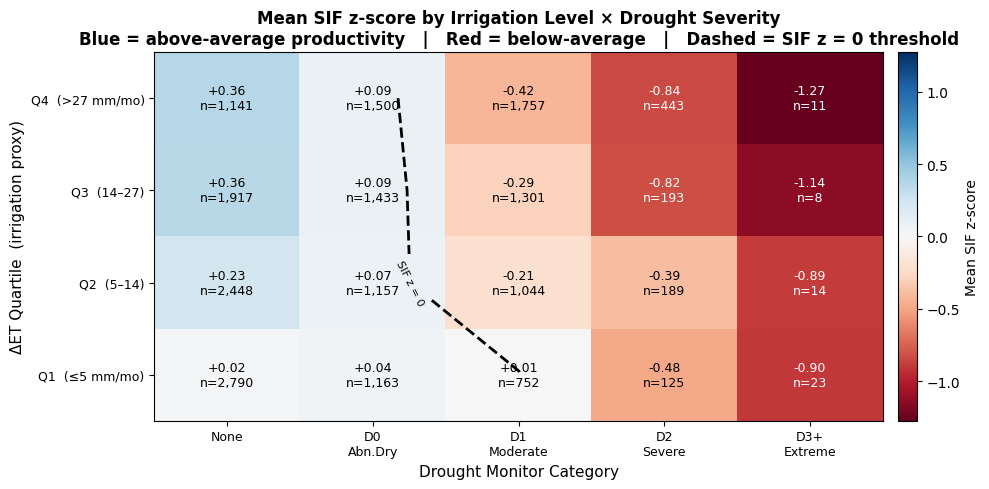

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/sif_heatmap_et_drought.png


In [17]:
# ΔET quartile boundaries — included in labels so axis is self-documenting
q_edges = df_gs_clean['et'].quantile([0.0, 0.25, 0.50, 0.75, 1.0]).values
et_labels = [
    f'Q1  (≤{q_edges[1]:.0f} mm/mo)',
    f'Q2  ({q_edges[1]:.0f}–{q_edges[2]:.0f})',
    f'Q3  ({q_edges[2]:.0f}–{q_edges[3]:.0f})',
    f'Q4  (>{q_edges[3]:.0f} mm/mo)',
]
print('ΔET quartile edges (mm/mo):', q_edges.round(1))

df_hm = df_gs_clean.copy()
df_hm['et_q'] = pd.qcut(df_hm['et'], q=4, labels=et_labels, duplicates='drop')

pivot_mean = (df_hm.groupby(['et_q', 'dm_cat'])['sif_z']
              .mean().unstack('dm_cat'))
pivot_n    = (df_hm.groupby(['et_q', 'dm_cat'])['sif_z']
              .count().unstack('dm_cat'))

# Q4 (most irrigation) at the top
pivot_mean = pivot_mean.iloc[::-1]
pivot_n    = pivot_n.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 5))

data = pivot_mean.values
vmax = np.nanmax(np.abs(data))
im = ax.imshow(data, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')

# Annotate each cell: mean SIF z and sample count
for i in range(pivot_mean.shape[0]):
    for j in range(pivot_mean.shape[1]):
        val = data[i, j]
        n   = pivot_n.values[i, j]
        if not np.isnan(val):
            txt_col = 'white' if abs(val) > vmax * 0.55 else 'black'
            ax.text(j, i, f'{val:+.2f}\nn={int(n):,}',
                    ha='center', va='center', fontsize=9, color=txt_col)

# Dashed zero-contour marks where irrigation buffering breaks down
filled = np.where(np.isnan(data), 0.0, data)
cs = ax.contour(filled, levels=[0], colors='k', linewidths=2, linestyles='--')
ax.clabel(cs, fmt='SIF z = 0', fontsize=8, inline=True)

ax.set_xticks(range(pivot_mean.shape[1]))
ax.set_xticklabels([DM_LABELS[c] for c in pivot_mean.columns], fontsize=9)
ax.set_yticks(range(pivot_mean.shape[0]))
ax.set_yticklabels(pivot_mean.index, fontsize=9)
ax.set_xlabel('Drought Monitor Category', fontsize=11)
ax.set_ylabel('ΔET Quartile  (irrigation proxy)', fontsize=11)
ax.set_title(
    'Mean SIF z-score by Irrigation Level × Drought Severity\n'
    'Blue = above-average productivity   |   Red = below-average   |   '
    'Dashed = SIF z = 0 threshold',
    fontsize=12, fontweight='bold'
)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Mean SIF z-score', fontsize=10)

plt.tight_layout()
plt.savefig(figures_dir / 'sif_heatmap_et_drought.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/sif_heatmap_et_drought.png')

## 12. Irrigation Buffering Gap Curve

**Buffering gap** = mean SIF z-score (High ΔET) − mean SIF z-score (Low ΔET) at each drought level. Shading = 95% CI on the difference (propagated from both group SEMs).

- **Positive gap** → irrigation is associated with higher-than-expected SIF relative to rainfed pixels under the same drought.
- **Gap crosses zero** → the drought severity at which irrigation provides no measurable productivity benefit — the **effective buffering threshold**.
- **Negative gap** → irrigated areas show *worse* SIF anomalies than rainfed areas, consistent with reactive pumping under conditions (heat, VPD) that irrigation cannot address.

Buffering gap by drought category:
 dm_cat       gap       ci  n_high  n_low
      0  0.238958 0.036947    3058   5238
      1  0.032103 0.042771    2933   2320
      2 -0.248457 0.043205    3059   1795
      3 -0.411627 0.075942     636    314
      4 -0.320972 0.229688      19     37


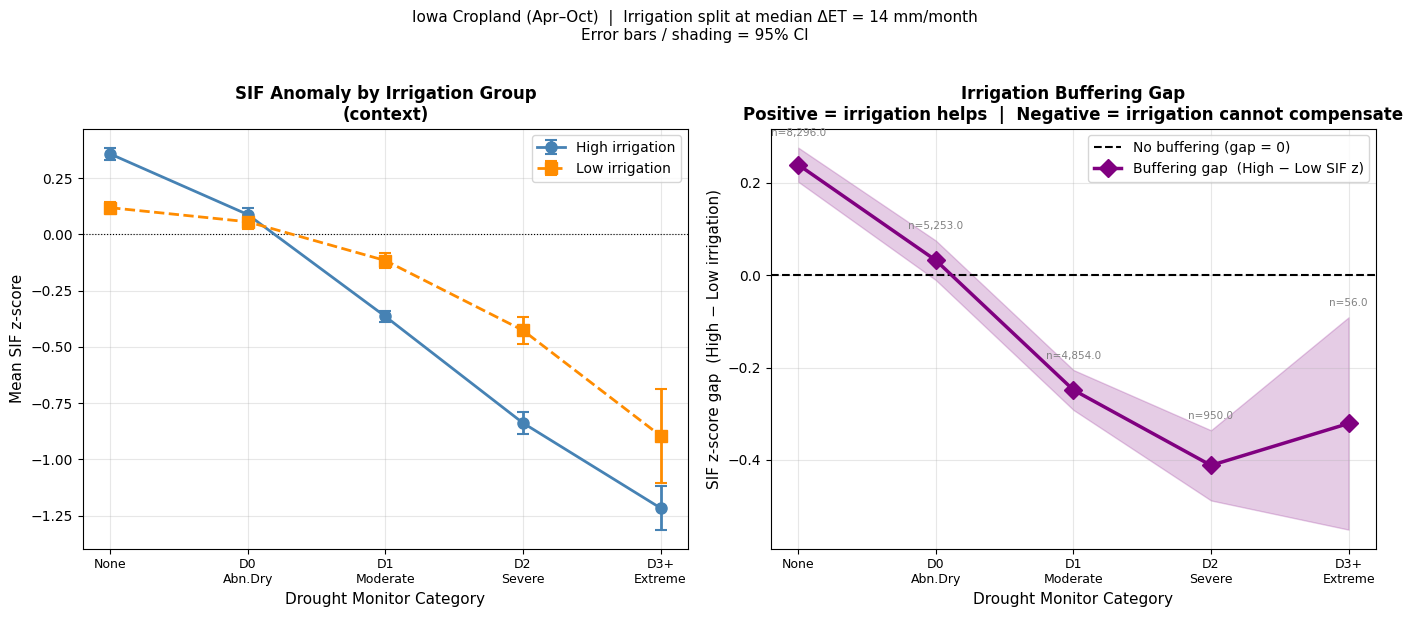

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/sif_buffering_gap.png


In [19]:
# Buffering gap = High irrigation SIF z − Low irrigation SIF z per drought category
# (irr_group assigned in Section 9)
stats = (df_gs_clean.groupby(['irr_group', 'dm_cat'])['sif_z']
         .agg(['mean', 'sem', 'count']).reset_index())

gap_rows = []
for cat in present_cats:
    h = stats[(stats['irr_group'] == 'High irrigation') & (stats['dm_cat'] == cat)]
    l = stats[(stats['irr_group'] == 'Low irrigation')  & (stats['dm_cat'] == cat)]
    if h.empty or l.empty:
        continue
    gap    = float(h['mean'].iloc[0]) - float(l['mean'].iloc[0])
    se_gap = np.sqrt(float(h['sem'].iloc[0])**2 + float(l['sem'].iloc[0])**2)
    gap_rows.append({'dm_cat': cat, 'gap': gap, 'ci': 1.96 * se_gap,
                     'n_high': int(h['count'].iloc[0]), 'n_low': int(l['count'].iloc[0])})

gap_df = pd.DataFrame(gap_rows)
print('Buffering gap by drought category:')
print(gap_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left panel: individual group means (context) ---
ax = axes[0]
for group, color, marker, ls in [
    ('High irrigation', 'steelblue',  'o', '-'),
    ('Low irrigation',  'darkorange', 's', '--'),
]:
    sub = stats[stats['irr_group'] == group].sort_values('dm_cat')
    ax.errorbar(sub['dm_cat'], sub['mean'], yerr=1.96 * sub['sem'],
                label=group, color=color, marker=marker,
                linestyle=ls, linewidth=2, markersize=8, capsize=4, capthick=1.5)

ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_xticks(present_cats)
ax.set_xticklabels(cat_labels, fontsize=9)
ax.set_xlabel('Drought Monitor Category', fontsize=11)
ax.set_ylabel('Mean SIF z-score', fontsize=11)
ax.set_title('SIF Anomaly by Irrigation Group\n(context)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Right panel: buffering gap ---
ax = axes[1]
ax.axhline(0, color='black', lw=1.5, ls='--', zorder=2, label='No buffering (gap = 0)')
ax.fill_between(gap_df['dm_cat'],
                gap_df['gap'] - gap_df['ci'],
                gap_df['gap'] + gap_df['ci'],
                alpha=0.2, color='purple')
ax.plot(gap_df['dm_cat'], gap_df['gap'],
        color='purple', marker='D', linewidth=2.5, markersize=9, zorder=3,
        label='Buffering gap  (High − Low SIF z)')

# Annotate each point with n
for _, row in gap_df.iterrows():
    ax.annotate(f"n={row['n_high']+row['n_low']:,}",
                xy=(row['dm_cat'], row['gap'] + row['ci'] + 0.02),
                ha='center', va='bottom', fontsize=7.5, color='gray')

ax.set_xticks(present_cats)
ax.set_xticklabels(cat_labels, fontsize=9)
ax.set_xlabel('Drought Monitor Category', fontsize=11)
ax.set_ylabel('SIF z-score gap  (High − Low irrigation)', fontsize=11)
ax.set_title('Irrigation Buffering Gap\n'
             'Positive = irrigation helps  |  Negative = irrigation cannot compensate',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Iowa Cropland (Apr–Oct)  |  Irrigation split at median ΔET = {median_et:.0f} mm/month\n'
    f'Error bars / shading = 95% CI',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(figures_dir / 'sif_buffering_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/sif_buffering_gap.png')

## 11. Summary

In [16]:
print('=' * 65)
print('SIF x Irrigation x Drought Summary — Iowa 2019–2023')
print('=' * 65)
print(f'Growing-season pixel-month observations: {len(df_gs_clean):,}')
print(f'Irrigation split at median DeltaET:      {median_et:.1f} mm/month')
print()

print('Mean SIF by drought x irrigation group:')
pivot = (
    df_gs_clean
    .groupby(['irr_group', 'dm_cat'])['sif'].mean()
    .unstack('dm_cat').rename(columns=DM_LABELS)
)
print(pivot.round(3).to_string())
print()

print('Mean SIF z-score by drought x irrigation group:')
pivot_z = (
    df_gs_clean
    .groupby(['irr_group', 'dm_cat'])['sif_z'].mean()
    .unstack('dm_cat').rename(columns=DM_LABELS)
)
print(pivot_z.round(3).to_string())

# Save summary CSV
out_csv = output_dir / 'sif_irr_drought_summary.csv'
(
    df_gs_clean
    .groupby(['irr_group', 'dm_cat'])[['sif', 'sif_z', 'et', 'et_z']]
    .agg(['mean', 'std', 'count'])
    .to_csv(out_csv)
)
print(f'\nSummary CSV: {out_csv}')
print(f'Figures:     {figures_dir}')

SIF x Irrigation x Drought Summary — Iowa 2019–2023
Growing-season pixel-month observations: 19,409
Irrigation split at median DeltaET:      14.3 mm/month

Mean SIF by drought x irrigation group:
dm_cat            None  D0\nAbn.Dry  D1\nModerate  D2\nSevere  D3+\nExtreme
irr_group                                                                  
High irrigation  0.449        0.434         0.414       0.385         0.154
Low irrigation   0.273        0.179         0.164       0.096         0.119

Mean SIF z-score by drought x irrigation group:
dm_cat            None  D0\nAbn.Dry  D1\nModerate  D2\nSevere  D3+\nExtreme
irr_group                                                                  
High irrigation  0.358        0.088        -0.365      -0.838        -1.216
Low irrigation   0.119        0.056        -0.116      -0.426        -0.895

Summary CSV: /home/pielab-sandbox-jcoldiron/SIF-Analysis/data/processed/sif_irr_drought/sif_irr_drought_summary.csv
Figures:     /home/pielab-sand